# Itô's Lemma

Itô's lemma is the **chain rule of stochastic calculus**. It tells us how a function 
of a stochastic process evolves.

## The Problem

For a smooth function $f(x)$ and a smooth path $X(t)$:

$$df(X(t)) = f'(X(t)) \, dX(t)$$

But Brownian motion $W(t)$ is **not differentiable**. The ordinary chain rule fails because:

$$(dW)^2 = dt \quad \text{(not zero!)}$$

## The Solution

For $f(W(t))$, we need the **second-order** Taylor expansion:

$$df = f'(W) \, dW + \frac{1}{2}f''(W) \, (dW)^2 = f'(W) \, dW + \frac{1}{2}f''(W) \, dt$$

The extra term $\frac{1}{2}f''(W) \, dt$ is the **Itô correction**.


## Itô's Lemma (1D)

If $X(t)$ follows an Itô process:

$$dX = \mu(X,t) \, dt + \sigma(X,t) \, dW$$

And $Y(t) = f(X(t), t)$, then:

$$\boxed{df = \frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial x} dX + \frac{1}{2}\frac{\partial^2 f}{\partial x^2} (dX)^2}$$

Expanding $(dX)^2$:

$$(dX)^2 = (\mu \, dt + \sigma \, dW)^2 = \sigma^2 \, dt$$

So:

$$\boxed{df = \left(\frac{\partial f}{\partial t} + \mu \frac{\partial f}{\partial x} + \frac{1}{2}\sigma^2 \frac{\partial^2 f}{\partial x^2}\right)dt + \sigma \frac{\partial f}{\partial x} dW}$$

## Intuition

| Term | Ordinary Calculus | Stochastic Calculus |
|------|-------------------|-------------------|
| $dt$ | Yes | Yes |
| $dW$ | No | Yes |
| $(dW)^2$ | 0 | $dt$ |
| $(dt)^2$ | 0 | 0 |
| $dt \cdot dW$ | 0 | 0 |

> **Mnemonic**: In stochastic calculus, keep terms up to order $dt$. Since $(dW)^2 = dt$, 
> the second-order term in $x$ survives.


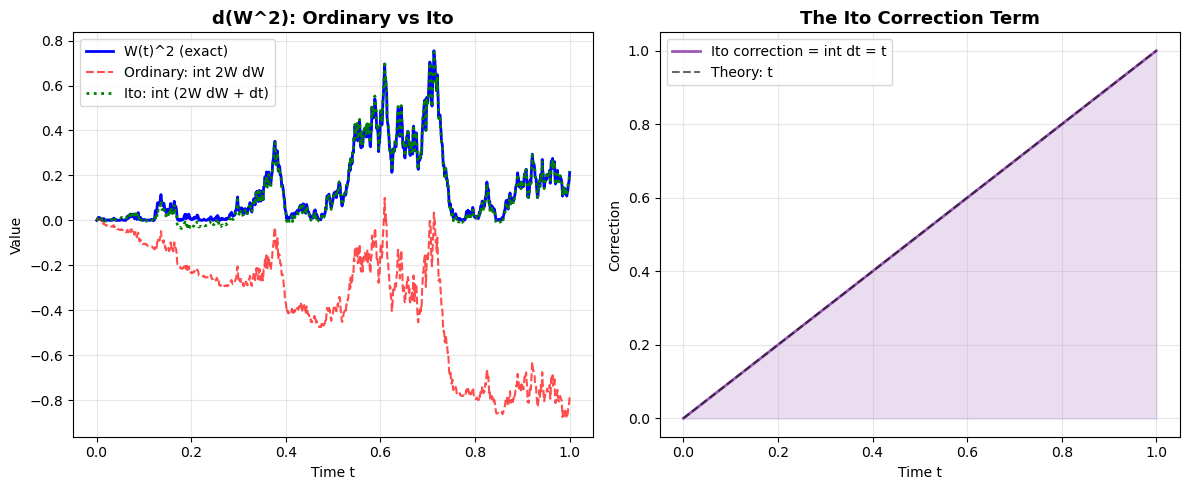

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(55)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N+1)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

# f(W) = W^2
W2 = W**2

# Ordinary calculus would say: d(W^2) = 2W dW
ordinary = np.concatenate([[0], np.cumsum(2 * W[:-1] * dW)])

# Ito says: d(W^2) = 2W dW + dt
ito = np.concatenate([[0], np.cumsum(2 * W[:-1] * dW + dt)])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, W2, 'b-', linewidth=2, label='W(t)^2 (exact)')
plt.plot(t, ordinary, 'r--', linewidth=1.5, alpha=0.7, label='Ordinary: int 2W dW')
plt.plot(t, ito, 'g:', linewidth=2, label='Ito: int (2W dW + dt)')
plt.title('d(W^2): Ordinary vs Ito', fontsize=13, fontweight='bold')
plt.xlabel('Time t')
plt.ylabel('Value')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
correction = ito - ordinary
plt.plot(t, correction, color='#9b59b6', linewidth=2, label='Ito correction = int dt = t')
plt.plot(t, t, 'k--', linewidth=1.5, alpha=0.6, label='Theory: t')
plt.fill_between(t, correction, alpha=0.2, color='#9b59b6')
plt.title('The Ito Correction Term', fontsize=13, fontweight='bold')
plt.xlabel('Time t')
plt.ylabel('Correction')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Where Does the Correction Come From?

### Taylor Expansion

$$df = f'(W) dW + \frac{1}{2}f''(W) (dW)^2 + \frac{1}{6}f'''(W) (dW)^3 + \cdots$$

For Brownian motion:
- $(dW)^2 = dt$ (order 1, **keep it!**)
- $(dW)^3 \approx (dt)^{3/2} \to 0$ (higher order, drop it)
- $(dt)^2 \to 0$ (higher order, drop it)

### Example: $f(W) = W^2$

$$f'(W) = 2W, \quad f''(W) = 2$$

$$d(W^2) = 2W \, dW + \frac{1}{2} \cdot 2 \cdot dt = 2W \, dW + dt$$

### Example: $f(W) = e^W$

$$f'(W) = e^W, \quad f''(W) = e^W$$

$$d(e^W) = e^W \, dW + \frac{1}{2} e^W \, dt = e^W \left(dW + \frac{1}{2}dt\right)$$

### Example: $f(W) = \sin(W)$

$$f'(W) = \cos(W), \quad f''(W) = -\sin(W)$$

$$d(\sin W) = \cos(W) \, dW - \frac{1}{2}\sin(W) \, dt$$


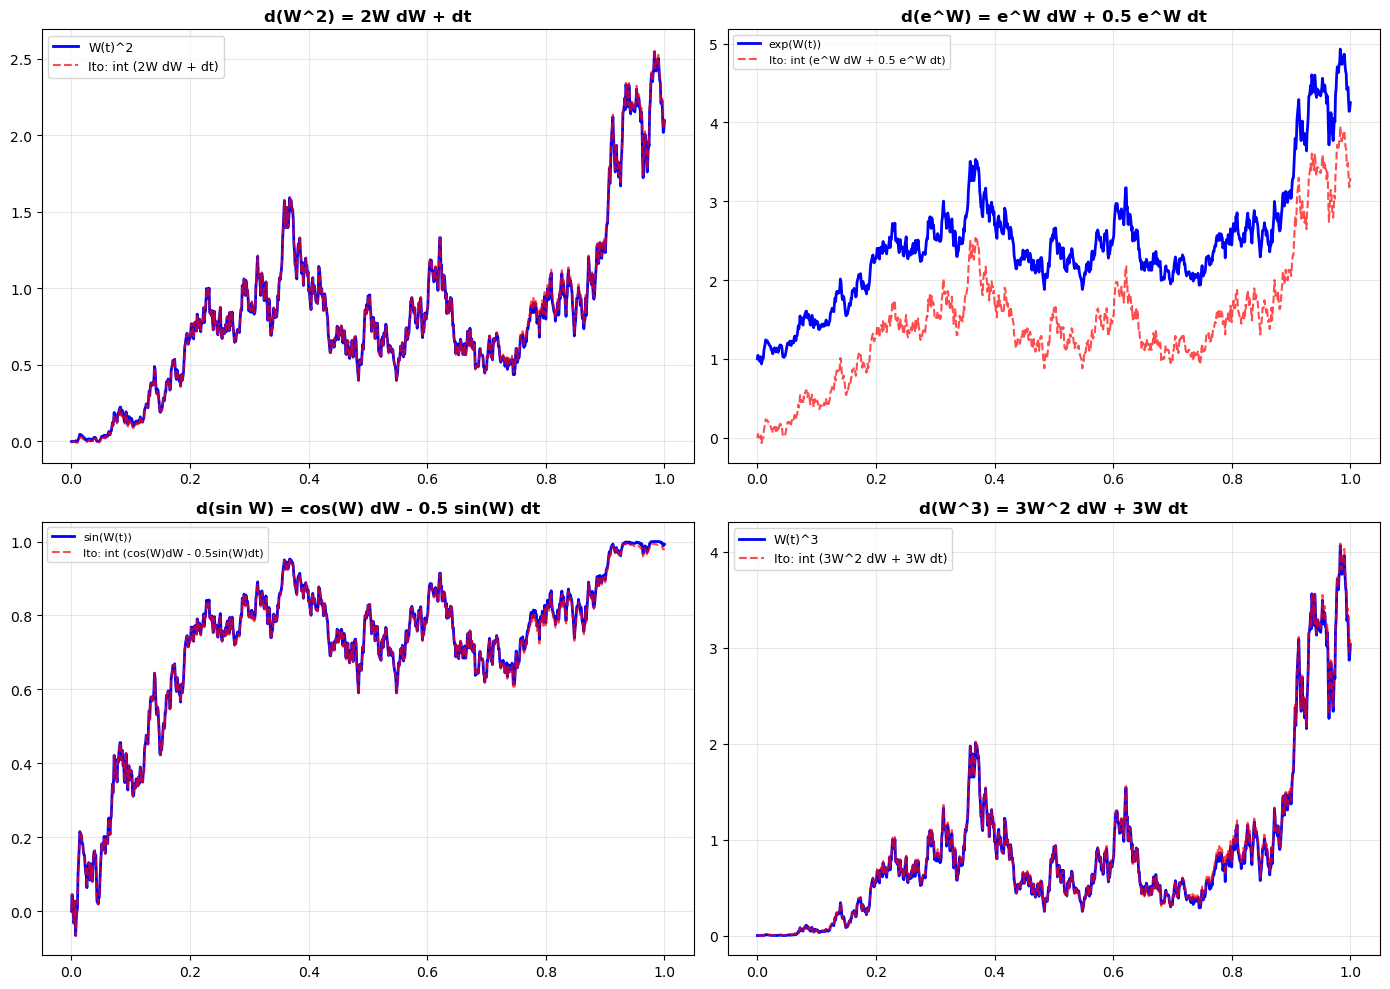

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

np.random.seed(66)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N+1)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

# --- f(W) = W^2 ---
ax = axes[0, 0]
f = W**2
ito_f = np.concatenate([[0], np.cumsum(2*W[:-1]*dW + dt)])
ax.plot(t, f, 'b-', linewidth=2, label='W(t)^2')
ax.plot(t, ito_f, 'r--', linewidth=1.5, alpha=0.7, label='Ito: int (2W dW + dt)')
ax.set_title('d(W^2) = 2W dW + dt', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- f(W) = exp(W) ---
ax = axes[0, 1]
f = np.exp(W)
ito_f = np.concatenate([[0], np.cumsum(np.exp(W[:-1])*dW + 0.5*np.exp(W[:-1])*dt)])
ax.plot(t, f, 'b-', linewidth=2, label='exp(W(t))')
ax.plot(t, ito_f, 'r--', linewidth=1.5, alpha=0.7, label='Ito: int (e^W dW + 0.5 e^W dt)')
ax.set_title('d(e^W) = e^W dW + 0.5 e^W dt', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- f(W) = sin(W) ---
ax = axes[1, 0]
f = np.sin(W)
ito_f = np.concatenate([[0], np.cumsum(np.cos(W[:-1])*dW - 0.5*np.sin(W[:-1])*dt)])
ax.plot(t, f, 'b-', linewidth=2, label='sin(W(t))')
ax.plot(t, ito_f, 'r--', linewidth=1.5, alpha=0.7, label='Ito: int (cos(W)dW - 0.5sin(W)dt)')
ax.set_title('d(sin W) = cos(W) dW - 0.5 sin(W) dt', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- f(W) = W^3 ---
ax = axes[1, 1]
f = W**3
ito_f = np.concatenate([[0], np.cumsum(3*W[:-1]**2*dW + 3*W[:-1]*dt)])
ax.plot(t, f, 'b-', linewidth=2, label='W(t)^3')
ax.plot(t, ito_f, 'r--', linewidth=1.5, alpha=0.7, label='Ito: int (3W^2 dW + 3W dt)')
ax.set_title('d(W^3) = 3W^2 dW + 3W dt', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Application: Deriving the GBM Solution

Recall the GBM SDE:

$$\frac{dS}{S} = \mu \, dt + \sigma \, dW$$

We want to find $S(t)$. Let $Y = \ln(S)$.

### Apply Itô's Lemma

$$f(S) = \ln(S) \quad \Rightarrow \quad f'(S) = \frac{1}{S}, \quad f''(S) = -\frac{1}{S^2}$$

$$d(\ln S) = \frac{1}{S} dS + \frac{1}{2}\left(-\frac{1}{S^2}\right)(dS)^2$$

Substitute $dS = \mu S \, dt + \sigma S \, dW$:

$$d(\ln S) = \frac{1}{S}(\mu S \, dt + \sigma S \, dW) - \frac{1}{2S^2}(\sigma^2 S^2 \, dt)$$

$$= \mu \, dt + \sigma \, dW - \frac{\sigma^2}{2} dt$$

$$\boxed{d(\ln S) = \left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma \, dW}$$

### Integrate

$$\ln(S(t)) = \ln(S_0) + \left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W(t)$$

### Exponentiate

$$\boxed{S(t) = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W(t)\right]}$$

> **Without the Itô correction** $-\sigma^2/2$, the expected value would be wrong:
> $\mathbb{E}[S(t)] = S_0 e^{\mu t}$ requires the correction!


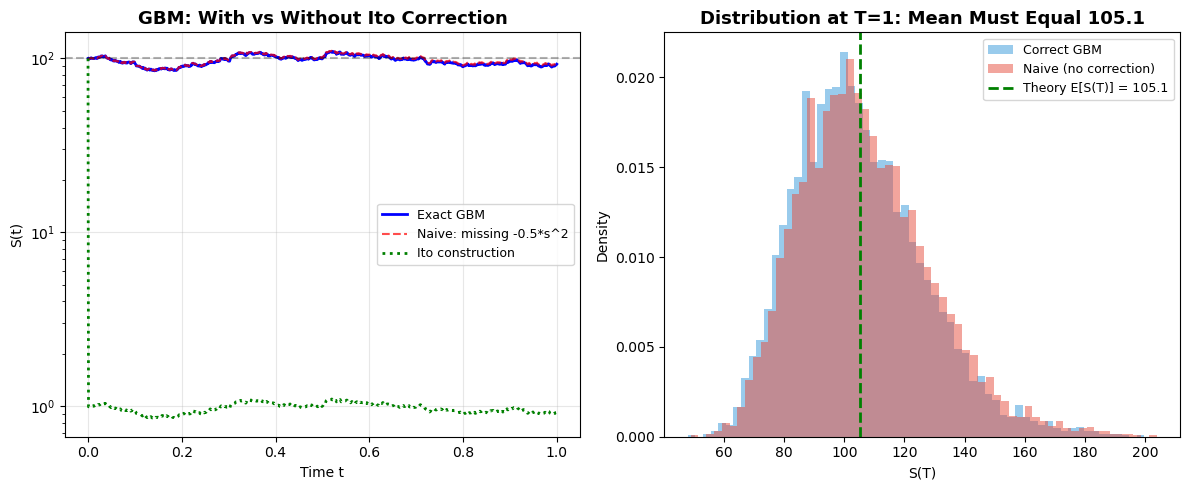

Correct mean S(T): 104.94 (theory: 105.13)
Naive mean S(T):   107.06 (WRONG!)


In [3]:
np.random.seed(100)
S0, mu, sigma = 100, 0.05, 0.2
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N+1)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

# Exact GBM solution
S_exact = S0 * np.exp((mu - 0.5*sigma**2)*t + sigma*W)

# Naive (wrong): d(ln S) = mu dt + sigma dW  (missing -0.5*sigma^2)
S_naive = S0 * np.exp(mu*t + sigma*W)

# Ito construction: d(ln S) = (mu - 0.5*sigma^2)dt + sigma dW
lnS_ito = np.concatenate([[np.log(S0)], np.cumsum((mu - 0.5*sigma**2)*dt + sigma*dW)])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t, S_exact, 'b-', linewidth=2, label='Exact GBM')
plt.plot(t, S_naive, 'r--', linewidth=1.5, alpha=0.7, label='Naive: missing -0.5*s^2')
plt.plot(t, np.exp(lnS_ito), 'g:', linewidth=2, label='Ito construction')
plt.axhline(y=S0, color='black', linestyle='--', alpha=0.3)
plt.title('GBM: With vs Without Ito Correction', fontsize=13, fontweight='bold')
plt.xlabel('Time t')
plt.ylabel('S(t)')
plt.legend(fontsize=9)
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Verify expected value
n_sims = 5000
S_T = []
S_T_naive = []
for _ in range(n_sims):
    dW_sim = np.random.normal(0, np.sqrt(dt), N)
    W_sim = np.cumsum(dW_sim)
    S_T.append(S0 * np.exp((mu - 0.5*sigma**2)*T + sigma*W_sim[-1]))
    S_T_naive.append(S0 * np.exp(mu*T + sigma*W_sim[-1]))

plt.hist(S_T, bins=60, density=True, alpha=0.5, color='#3498db', label='Correct GBM')
plt.hist(S_T_naive, bins=60, density=True, alpha=0.5, color='#e74c3c', label='Naive (no correction)')
plt.axvline(x=S0*np.exp(mu*T), color='green', linestyle='--', linewidth=2, 
            label='Theory E[S(T)] = %.1f' % (S0*np.exp(mu*T)))
plt.title('Distribution at T=1: Mean Must Equal %.1f' % (S0*np.exp(mu*T)), 
          fontsize=13, fontweight='bold')
plt.xlabel('S(T)')
plt.ylabel('Density')
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Correct mean S(T): {np.mean(S_T):.2f} (theory: {S0*np.exp(mu*T):.2f})")
print(f"Naive mean S(T):   {np.mean(S_T_naive):.2f} (WRONG!)")


## Product Rule for Itô Processes

For two Itô processes $X(t)$ and $Y(t)$:

$$\boxed{d(XY) = X \, dY + Y \, dX + dX \, dY}$$

The extra term $dX \, dY$ is the **covariation**.

If $dX = \mu_X dt + \sigma_X dW_X$ and $dY = \mu_Y dt + \sigma_Y dW_Y$ with 
$\text{Corr}(dW_X, dW_Y) = \rho$:

$$dX \, dY = \sigma_X \sigma_Y \rho \, dt$$

### Example: $f(t, W) = t \cdot W(t)$

Here $X(t) = t$ (deterministic, $dX = dt$) and $Y(t) = W(t)$ ($dY = dW$).

$$d(tW) = t \, dW + W \, dt + dt \cdot dW = t \, dW + W \, dt$$

### Integration by Parts

$$\int_0^T W(s) \, ds = T \cdot W(T) - \int_0^T s \, dW(s)$$

This follows from the product rule applied to $t \cdot W(t)$.


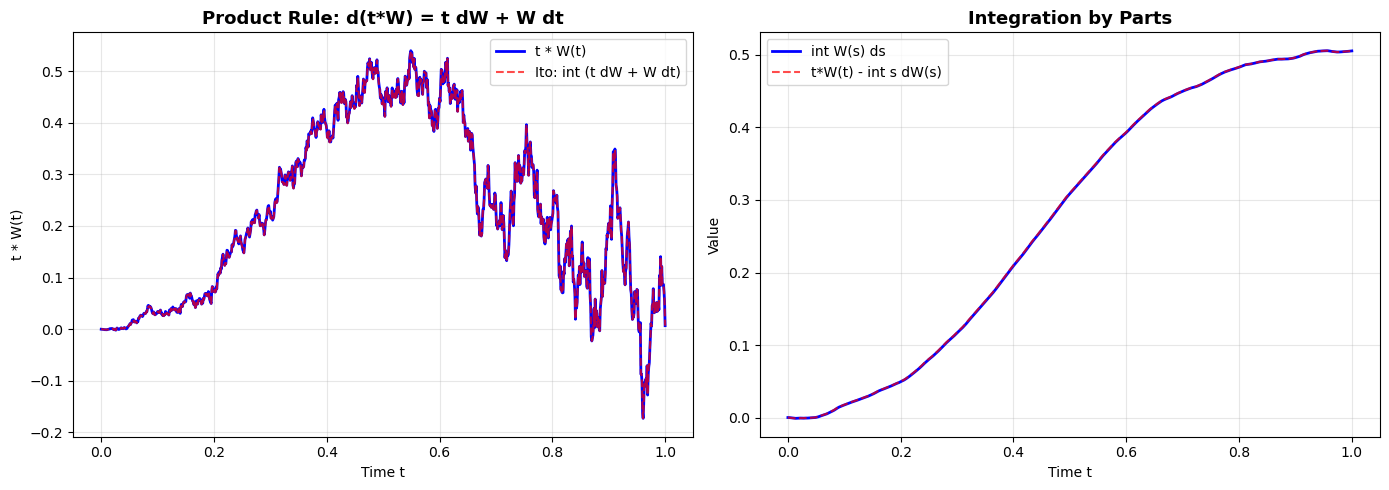

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

np.random.seed(300)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N+1)
dW = np.random.normal(0, np.sqrt(dt), N)
W = np.concatenate([[0], np.cumsum(dW)])

# --- Left: Product rule d(t*W) = t dW + W dt ---
ax = axes[0]
f = t * W
ito_f = np.concatenate([[0], np.cumsum(t[:-1]*dW + W[:-1]*dt)])
ax.plot(t, f, 'b-', linewidth=2, label='t * W(t)')
ax.plot(t, ito_f, 'r--', linewidth=1.5, alpha=0.7, label='Ito: int (t dW + W dt)')
ax.set_title('Product Rule: d(t*W) = t dW + W dt', fontsize=13, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('t * W(t)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Right: Integration by parts ---
ax = axes[1]
left = np.concatenate([[0], np.cumsum(W[:-1]*dt)])
right = t*W - np.concatenate([[0], np.cumsum(t[:-1]*dW)])
ax.plot(t, left, 'b-', linewidth=2, label='int W(s) ds')
ax.plot(t, right, 'r--', linewidth=1.5, alpha=0.7, label='t*W(t) - int s dW(s)')
ax.set_title('Integration by Parts', fontsize=13, fontweight='bold')
ax.set_xlabel('Time t')
ax.set_ylabel('Value')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Multi-Dimensional Itô's Lemma

For $f(X_1, X_2, \ldots, X_n, t)$ where each $X_i$ is an Itô process:

$$\boxed{df = \frac{\partial f}{\partial t} dt + \sum_{i=1}^{n} \frac{\partial f}{\partial x_i} dX_i + \frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{n} \frac{\partial^2 f}{\partial x_i \partial x_j} dX_i \, dX_j}$$

### The Cross-Terms

$$dX_i \, dX_j = \sigma_i \sigma_j \rho_{ij} \, dt$$

where $\rho_{ij}$ is the correlation between the Brownian motions driving $X_i$ and $X_j$.

### Example: $f(S_1, S_2) = S_1 \cdot S_2$

$$\frac{\partial f}{\partial S_1} = S_2, \quad \frac{\partial f}{\partial S_2} = S_1, \quad \frac{\partial^2 f}{\partial S_1 \partial S_2} = 1$$

$$d(S_1 S_2) = S_2 \, dS_1 + S_1 \, dS_2 + dS_1 \, dS_2$$

$$= S_2 \, dS_1 + S_1 \, dS_2 + \sigma_1 \sigma_2 \rho S_1 S_2 \, dt$$

### Example: $f(S_1, S_2) = S_1 / S_2$

$$d\left(\frac{S_1}{S_2}\right) = \frac{1}{S_2} dS_1 - \frac{S_1}{S_2^2} dS_2 + \frac{S_1}{S_2^3}(dS_2)^2 - \frac{1}{S_2^2} dS_1 \, dS_2$$


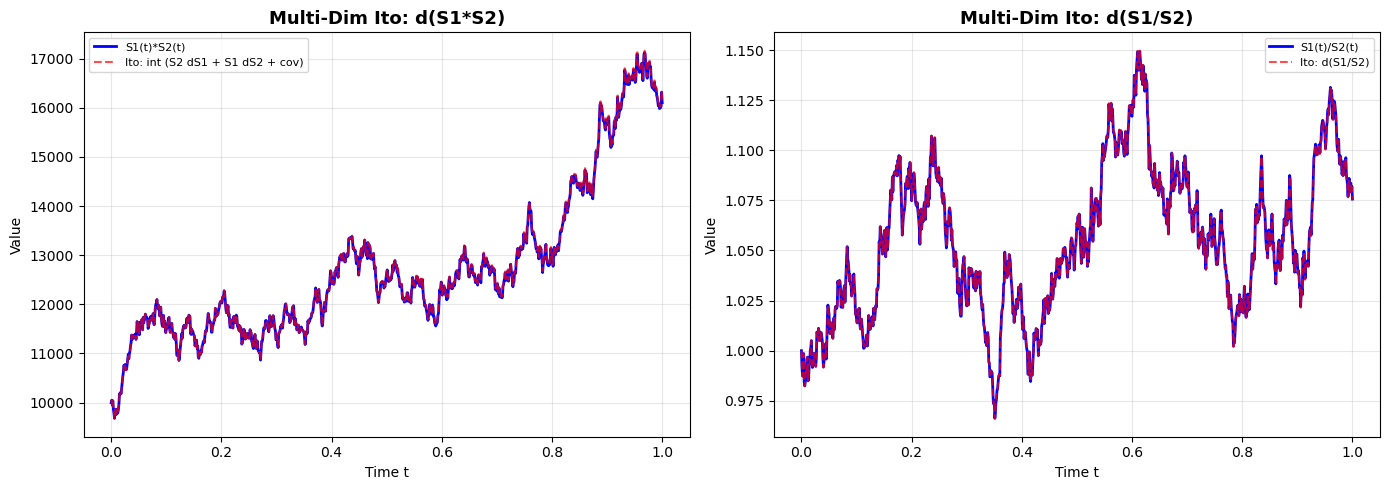

In [5]:
np.random.seed(700)
S0_1, S0_2 = 100, 100
mu1, mu2 = 0.05, 0.03
sigma1, sigma2 = 0.2, 0.15
rho = 0.5
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N+1)

# Correlated Brownian motions
dW1 = np.random.normal(0, np.sqrt(dt), N)
dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt), N)

S1 = S0_1 * np.exp((mu1 - 0.5*sigma1**2)*t + sigma1*np.concatenate([[0], np.cumsum(dW1)]))
S2 = S0_2 * np.exp((mu2 - 0.5*sigma2**2)*t + sigma2*np.concatenate([[0], np.cumsum(dW2)]))

plt.figure(figsize=(14, 5))

# --- Left: f = S1 * S2 ---
plt.subplot(1, 2, 1)
f = S1 * S2
f_ito = np.zeros(N+1)
f_ito[0] = S0_1 * S0_2
for i in range(N):
    dS1 = S1[i+1] - S1[i]
    dS2 = S2[i+1] - S2[i]
    f_ito[i+1] = f_ito[i] + S2[i]*dS1 + S1[i]*dS2 + sigma1*sigma2*rho*S1[i]*S2[i]*dt

plt.plot(t, f, 'b-', linewidth=2, label='S1(t)*S2(t)')
plt.plot(t, f_ito, 'r--', linewidth=1.5, alpha=0.7, label='Ito: int (S2 dS1 + S1 dS2 + cov)')
plt.title('Multi-Dim Ito: d(S1*S2)', fontsize=13, fontweight='bold')
plt.xlabel('Time t')
plt.ylabel('Value')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# --- Right: f = S1 / S2 ---
plt.subplot(1, 2, 2)
f_ratio = S1 / S2
f_ito_ratio = np.zeros(N+1)
f_ito_ratio[0] = S0_1 / S0_2
for i in range(N):
    dS1 = S1[i+1] - S1[i]
    dS2 = S2[i+1] - S2[i]
    f_ito_ratio[i+1] = f_ito_ratio[i] + (1/S2[i])*dS1 - (S1[i]/S2[i]**2)*dS2 + \
                       (S1[i]/S2[i]**3)*(sigma2*S2[i])**2*dt - (1/S2[i]**2)*sigma1*sigma2*rho*S1[i]*S2[i]*dt

plt.plot(t, f_ratio, 'b-', linewidth=2, label='S1(t)/S2(t)')
plt.plot(t, f_ito_ratio, 'r--', linewidth=1.5, alpha=0.7, label='Ito: d(S1/S2)')
plt.title('Multi-Dim Ito: d(S1/S2)', fontsize=13, fontweight='bold')
plt.xlabel('Time t')
plt.ylabel('Value')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## The Black-Scholes PDE from Itô's Lemma

Consider a European call option with price $V(S, t)$ where $S$ follows GBM:

$$dS = \mu S \, dt + \sigma S \, dW$$

### Apply Itô's Lemma to $V(S, t)$

$$dV = \frac{\partial V}{\partial t} dt + \frac{\partial V}{\partial S} dS + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}(dS)^2$$

$$= \left(\frac{\partial V}{\partial t} + \mu S \frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}\right)dt + \sigma S \frac{\partial V}{\partial S} dW$$

### Construct a Riskless Portfolio

Hold **1 option** and short **$\Delta = \frac{\partial V}{\partial S}$** shares of stock.

Portfolio value: $\Pi = V - \Delta S$

$$d\Pi = dV - \Delta \, dS = \left(\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}\right)dt$$

The $dW$ term **cancels**! The portfolio is riskless, so it must earn the risk-free rate:

$$d\Pi = r\Pi \, dt = r(V - \Delta S)dt$$

### The Black-Scholes PDE

$$\boxed{\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} = rV}$$

With boundary condition $V(S, T) = \max(S - K, 0)$ for a call option.


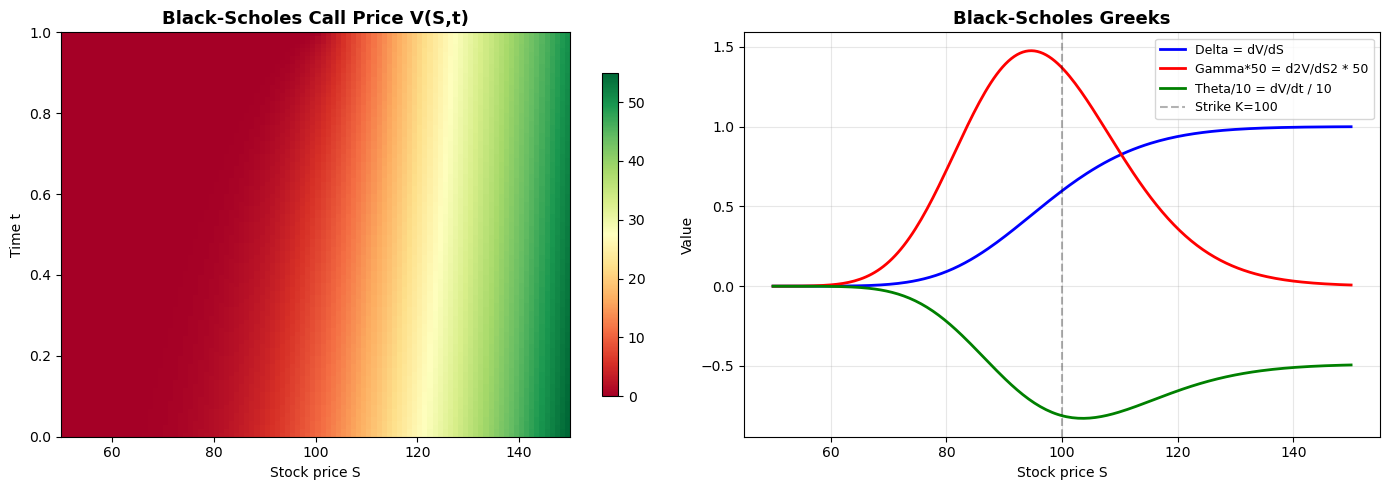

In [6]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Call price surface ---
ax = axes[0]
S_range = np.linspace(50, 150, 100)
t_range = np.linspace(0, 1, 100)
S_grid, t_grid = np.meshgrid(S_range, t_range)

K, r, sigma = 100, 0.05, 0.2

def call_price(S, t, K, r, sigma):
    tau = np.maximum(1 - t, 0.001)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r*tau) * norm.cdf(d2)

V = call_price(S_grid, t_grid, K, r, sigma)
im = ax.imshow(V, origin='lower', aspect='auto', cmap='RdYlGn',
               extent=[50, 150, 0, 1])
ax.set_title('Black-Scholes Call Price V(S,t)', fontsize=13, fontweight='bold')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Time t')
plt.colorbar(im, ax=ax, shrink=0.8)

# --- Right: Greeks ---
ax = axes[1]
S_range = np.linspace(50, 150, 200)
tau = 0.5
d1 = (np.log(S_range/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
d2 = d1 - sigma*np.sqrt(tau)

delta = norm.cdf(d1)
gamma = norm.pdf(d1) / (S_range * sigma * np.sqrt(tau))
theta = -(S_range * norm.pdf(d1) * sigma) / (2*np.sqrt(tau)) - r*K*np.exp(-r*tau)*norm.cdf(d2)

ax.plot(S_range, delta, 'b-', linewidth=2, label='Delta = dV/dS')
ax.plot(S_range, gamma*50, 'r-', linewidth=2, label='Gamma*50 = d2V/dS2 * 50')
ax.plot(S_range, theta/10, 'g-', linewidth=2, label='Theta/10 = dV/dt / 10')
ax.axvline(x=K, color='black', linestyle='--', alpha=0.3, label='Strike K=100')
ax.set_title('Black-Scholes Greeks', fontsize=13, fontweight='bold')
ax.set_xlabel('Stock price S')
ax.set_ylabel('Value')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Complete Formula Reference

### Itô's Lemma (1D)
$$df = \frac{\partial f}{\partial t} dt + \frac{\partial f}{\partial x} dX + \frac{1}{2}\frac{\partial^2 f}{\partial x^2}(dX)^2$$

### Common Derivatives
| $f(X)$ | $df$ |
|--------|------|
| $W^2$ | $2W \, dW + dt$ |
| $W^3$ | $3W^2 \, dW + 3W \, dt$ |
| $e^W$ | $e^W \, dW + \frac{1}{2}e^W \, dt$ |
| $\sin(W)$ | $\cos(W) \, dW - \frac{1}{2}\sin(W) \, dt$ |
| $\ln(S)$ | $\frac{dS}{S} - \frac{\sigma^2}{2}dt$ |

### Product Rule
$$d(XY) = X \, dY + Y \, dX + dX \, dY$$

### Integration by Parts
$$\int_0^T X \, dY = X(T)Y(T) - X(0)Y(0) - \int_0^T Y \, dX - [X, Y](T)$$

### Multi-Dimensional Itô's Lemma
$$df = \frac{\partial f}{\partial t} dt + \sum_i \frac{\partial f}{\partial x_i} dX_i + \frac{1}{2}\sum_{i,j} \frac{\partial^2 f}{\partial x_i \partial x_j} dX_i \, dX_j$$

### Black-Scholes PDE
$$\frac{\partial V}{\partial t} + rS\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} = rV$$
